In [1]:
# Import libraries
import pandas as pd
import xgboost as xgb
import shap
print(xgb.__version__, shap.__version__)

3.2.0 0.51.0


In [2]:
# Get the data
data = pd.read_csv("data/car_prices.csv")
data.head()

,Unnamed: 0,Price,Mileage,Cylinder,Doors,Cruise,Sound,Leather,Buick,Cadillac,Chevy,Pontiac,Saab,Saturn,convertible,coupe,hatchback,sedan,wagon
0,1,22661.05,20105,6,4,1,0,0,1,0,0,0,0,0,0,0,0,1,0
1,2,21725.01,13457,6,2,1,1,0,0,0,1,0,0,0,0,1,0,0,0
2,3,29142.71,31655,4,2,1,1,1,0,0,0,0,1,0,1,0,0,0,0
3,4,30731.94,22479,4,2,1,0,0,0,0,0,0,1,0,1,0,0,0,0
4,5,33358.77,17590,4,2,1,1,1,0,0,0,0,1,0,1,0,0,0,0


In [3]:
# Remove unwanted variable
data = data.iloc[:,1:]
data.head()

,Price,Mileage,Cylinder,Doors,Cruise,Sound,Leather,Buick,Cadillac,Chevy,Pontiac,Saab,Saturn,convertible,coupe,hatchback,sedan,wagon
0,22661.05,20105,6,4,1,0,0,1,0,0,0,0,0,0,0,0,1,0
1,21725.01,13457,6,2,1,1,0,0,0,1,0,0,0,0,1,0,0,0
2,29142.71,31655,4,2,1,1,1,0,0,0,0,1,0,1,0,0,0,0
3,30731.94,22479,4,2,1,0,0,0,0,0,0,1,0,1,0,0,0,0
4,33358.77,17590,4,2,1,1,1,0,0,0,0,1,0,1,0,0,0,0


In [4]:
# Isolate X and y
y = data.Price
X = data.iloc[:, 1:]

In [5]:
# Create Train and Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 1502)
X_test.head()

,Mileage,Cylinder,Doors,Cruise,Sound,Leather,Buick,Cadillac,Chevy,Pontiac,Saab,Saturn,convertible,coupe,hatchback,sedan,wagon
524,22891,6,4,1,1,1,0,0,0,1,0,0,0,0,0,1,0
344,7278,4,4,0,0,0,0,0,1,0,0,0,0,0,0,1,0
45,9795,4,4,1,1,1,0,0,0,0,1,0,0,0,0,1,0
144,14095,8,4,1,0,1,0,1,0,0,0,0,0,0,0,1,0
507,32458,4,4,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [6]:
# Create XGBoost matrices
Train = xgb.DMatrix(X_train, label = y_train)
Test = xgb.DMatrix(X_test, label = y_test)

# XGBoost

In [7]:
# Parameters
parameters = {'learning_rate': 0.3,
              'max_depth': 6,
              'colsample_bytree': 1,
              'subsample': 1,
              'min_child_weight': 1,
              'gamma': 0,
              'random_state': 1502,
              'eval_metric': "rmse",
              'objective': "reg:squarederror"}

In [8]:
# XGBoost model
model = xgb.train(params = parameters,
                  dtrain = Train,
                  num_boost_round  = 15,
                  evals = [(Test, "Price")],
                  verbose_eval = 2)

[0]	Price-rmse:6588.80856
[2]	Price-rmse:3968.85769
[4]	Price-rmse:2913.84400
[6]	Price-rmse:2498.93427
[8]	Price-rmse:2401.58706
[10]	Price-rmse:2344.31185
[12]	Price-rmse:2358.43694
[14]	Price-rmse:2377.79308


In [9]:
# Predictions
predictions = model.predict(Test)
predictions[:5]

array([18160.904, 12413.571, 30067.799, 41024.098, 11616.288],
      dtype=float32)

In [10]:
# Model assessment
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
print(round(mean_absolute_error(y_test, predictions),0))
print(round(mean_squared_error(y_test, predictions),0))
print(round(np.sqrt(mean_squared_error(y_test, predictions)),0))

1659.0
5653900.0
2378.0


# SHAP

In [11]:
# Preparation
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [12]:
# Local interpretability
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[3,:],X_test.loc[144])

In [13]:
X_test.head()

,Mileage,Cylinder,Doors,Cruise,Sound,Leather,Buick,Cadillac,Chevy,Pontiac,Saab,Saturn,convertible,coupe,hatchback,sedan,wagon
524,22891,6,4,1,1,1,0,0,0,1,0,0,0,0,0,1,0
344,7278,4,4,0,0,0,0,0,1,0,0,0,0,0,0,1,0
45,9795,4,4,1,1,1,0,0,0,0,1,0,0,0,0,1,0
144,14095,8,4,1,0,1,0,1,0,0,0,0,0,0,0,1,0
507,32458,4,4,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [14]:
shap_values

array([[-7.3585901e+02,  6.6483240e+02, -2.0314261e+02, ...,
         3.9148674e+01, -8.8986717e+01, -3.6449177e+01],
       [ 1.6649830e+03, -5.1612109e+03, -1.5631328e+02, ...,
         7.8229271e+01, -6.1522247e+01, -9.0022430e+01],
       [ 1.6468630e+03, -2.7259614e+03, -8.4642224e+02, ...,
         4.1053242e+01, -3.3544141e+02, -2.0138626e+00],
       ...,
       [-3.3133591e+02,  1.8553322e+02,  4.7419122e+02, ...,
         2.5011759e+01,  7.2584732e+01, -9.5512680e+01],
       [-8.8778870e+02, -4.0665022e+03,  4.6454031e+02, ...,
         5.6161118e+01,  1.1053788e+02, -1.2359917e+02],
       [-5.6977948e+02,  7.6874646e+02, -2.0279701e+02, ...,
         3.7612511e+01, -9.7661476e+01, -4.0114437e+01]],
      shape=(161, 17), dtype=float32)

In [15]:
#A ll local interpretation
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X_test)

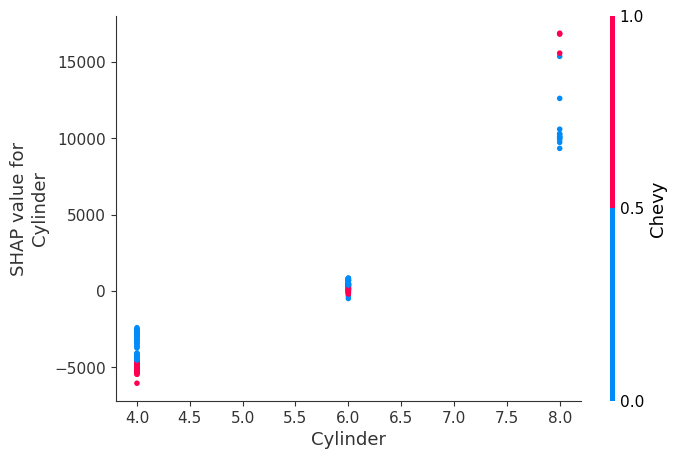

In [16]:
# Dependency plots
shap.dependence_plot("Cylinder", shap_values, X_test)

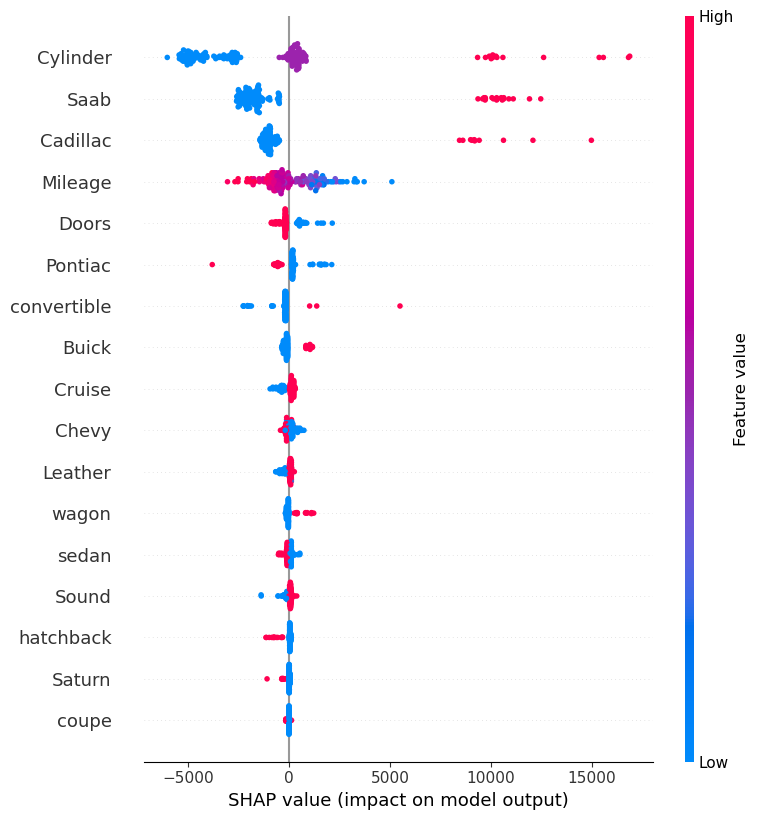

In [17]:
# Summary plot
shap.summary_plot(shap_values, X_test)

In [18]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 4.1 MB/s  0:00:03a 0:00:010:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939220 sha256=b4704000637c21b16fe536c1461f8859b9591f6d7239bdd56737b8a546ea5098
  Stored in directory: /home/michalek/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [19]:
# Import libraries
from pydataset import data 
import pandas as pd
import xgboost as xgb

initiated datasets repo at: /home/michalek/.pydataset/


In [20]:
# Data
data = data('Housing')
data.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [21]:
#Transform string variables
dataset = pd.get_dummies(data, drop_first=True)
dataset.head()

,price,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes
1,42000.0,5850,3,1,2,1,True,False,True,False,False,False
2,38500.0,4000,2,1,1,0,True,False,False,False,False,False
3,49500.0,3060,3,1,1,0,True,False,False,False,False,False
4,60500.0,6650,3,1,2,0,True,True,False,False,False,False
5,61000.0,6360,2,1,1,0,True,False,False,False,False,False


In [22]:
# Isolate X and y
y = dataset.price
X = dataset.iloc[:,1:]

In [23]:
# Create XGBoost Matrix
Train = xgb.DMatrix(X, label = y)

# XGBoost

In [25]:
# Set parameters
parameters = {'learning_rate': 0.3,
              'max_depth': 6,
              'colsample_bytree': 1,
              'subsample': 1,
              'min_child_weight': 1,
              'gamma': 0,
              'random_state':1502,
              'eval_metric': "rmse",
              'objective': "reg:squarederror"}

In [26]:
# Running XGBoost
model = xgb.train(params = parameters,
                  dtrain = Train,
                  num_boost_round = 15)

# SHAP

In [27]:
# Prepare SHAP
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [28]:
# Local interpretability
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X.loc[1])

In [29]:
shap_values

array([[ -1511.0952 ,    506.86603,  -4886.5425 , ...,   -493.7726 ,
         -4762.8784 ,  -2622.5981 ],
       [ -6518.344  ,  -2958.9639 ,  -4051.324  , ...,   -427.6209 ,
         -2368.2524 ,  -1682.8002 ],
       [-11604.293  ,    932.14386,  -4226.688  , ...,   -307.9655 ,
         -2263.2969 ,  -1509.7001 ],
       ...,
       [ 14790.878  ,    545.3993 ,   7595.295  , ...,   -132.114  ,
          8388.411  ,  -3035.5225 ],
       [ 16010.991  ,    361.2794 ,  11545.945  , ...,   -157.93332,
          8533.014  ,  -2833.4006 ],
       [ 20870.295  ,   1721.0825 ,  -6385.8574 , ...,   -160.42915,
          8331.916  ,  -1518.4612 ]], shape=(546, 11), dtype=float32)

In [30]:
X.head()

,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes
1,5850,3,1,2,1,True,False,True,False,False,False
2,4000,2,1,1,0,True,False,False,False,False,False
3,3060,3,1,1,0,True,False,False,False,False,False
4,6650,3,1,2,0,True,True,False,False,False,False
5,6360,2,1,1,0,True,False,False,False,False,False


In [31]:
# Local interpretability - plot all
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X)

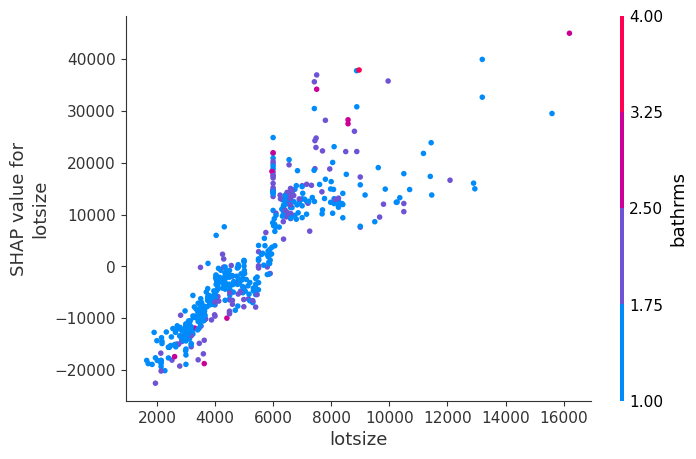

In [32]:
# Dependence plots
shap.dependence_plot("lotsize", shap_values, X)

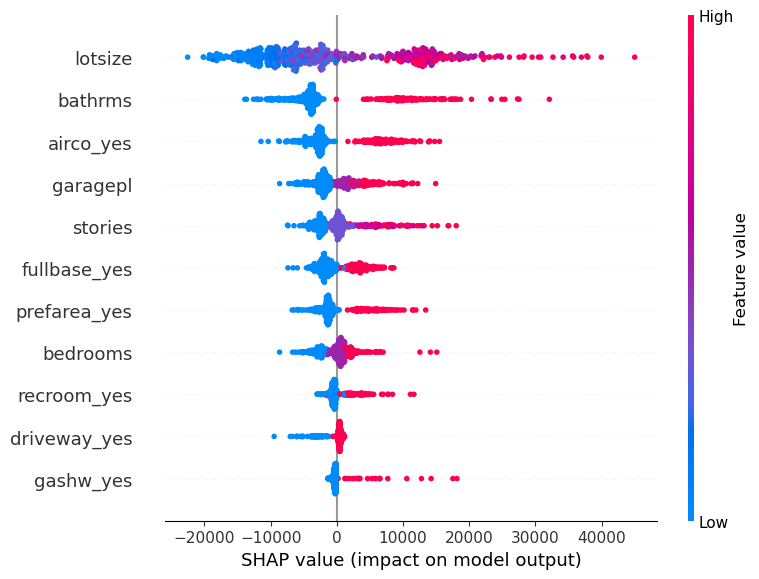

In [33]:
# Global Interpretability
shap.summary_plot(shap_values, X)